# Hotel Booking Cancellation Prediction

###Data Analysis


This section focuses on data analysis, starting with library installations and imports, and then proceeds with initial data loading and inspection.

In [ ]:
!pip install pytimetk
import pandas as pd
import numpy as np
from missingno import matrix
import pytimetk as tk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 51.4 MB/s eta 0:00:00
  Created wheel for supersmoother: filename=supersmoother-0.4-py3-none-any.whl size=16146 sha256=54f28a6a37486fc88f358227548d287caf69ebc02d132f5107c76e2545421947
  Stored in directory: /root/.cache/pip/wheels/69/4a/ff/05c85ded597955df839bedebe6dca56297c2568c04881d2e70
Successfully built supersmoother


### Library Imports

Here, we import the necessary libraries for data manipulation, analysis, and visualization. `pytimetk` is installed for time series analysis functionalities, although its full potential might be explored in later stages for time-related features. `pandas` and `numpy` are standard for data handling, and `missingno` is used for visualizing missing data patterns.

###Modeling

This section will cover the modeling approach, including model selection, training, and evaluation.

In [ ]:
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score

### Modeling Libraries

We import `statsmodels` for Generalized Linear Models (GLM), specifically `Binomial` family with a `logit` link for logistic regression, and `sklearn.metrics` for evaluating model performance with ROC AUC score.

###Data

This section handles the initial data loading from CSV files and combines them into a single DataFrame for further processing.

In [ ]:
df_h1 = pd.read_csv('H1.csv')
df_h2 = pd.read_csv('H2.csv')

joined_df = pd.concat([df_h1, df_h2], ignore_index=True)

joined_df.to_csv('joined_data.csv', index=False)
print('Files H1.csv and H2.csv have been joined and saved as joined_data.csv')

Files H1.csv and H2.csv have been joined and saved as joined_data.csv


### Data Loading and Concatenation

We load two separate datasets, `H1.csv` and `H2.csv`, representing different hotel booking data. These are then concatenated into a single DataFrame `joined_df` and saved as `joined_data.csv` for unified processing.

In [ ]:
df = pd.read_csv("joined_data.csv")

### Load Unified Data

The combined dataset `joined_data.csv` is loaded into a pandas DataFrame `df` for all subsequent analysis.

####Total no. of people cancel

### Standardizing Column Names

To ensure consistency and ease of use, all DataFrame column names are converted from camel case to snake case using a regular expression utility function. This makes column names more readable and Pythonic.

In [ ]:
import re

def camel_to_snake_case(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

df.columns = [camel_to_snake_case(col) for col in df.columns]
print("DataFrame columns converted to snake_case:")
print(df.columns)

DataFrame columns converted to snake_case:
Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


### Cancellation Count Analysis

This code block calculates the total number and proportion of canceled bookings (`is_canceled` = 1) versus non-canceled bookings (`is_canceled` = 0) in the dataset. This gives a quick overview of the cancellation rate.

In [ ]:
cancel_count = df["is_canceled"].value_counts().reset_index()
cancel_count.columns = ["is_canceled","n"]
cancel_count["prop"] = cancel_count["n"]/cancel_count["n"].sum()
cancel_count

,is_canceled,n,prop
0,0,75166,0.629584
1,1,44224,0.370416


### Average Daily Rate (ADR) and Stay Duration

Here, we calculate the average daily rate (ADR) charged to guests and the average total number of stay days. The `total_stay_days` is a new feature derived from `stays_in_weekend_nights` and `stays_in_week_nights`.

In [ ]:
average_adr = df['adr'].mean()
df['total_stay_days'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
average_stay_days = df['total_stay_days'].mean()

print(f"Average Price (ADR) of Hotel: {average_adr:.2f}")
print(f"Average Number of Stay Days: {average_stay_days:.2f}")

Average Price (ADR) of Hotel: 101.83
Average Number of Stay Days: 3.43


### Quantifying Potential Revenue Loss from Cancellations

This calculation estimates the potential revenue lost due to cancellations by multiplying the number of canceled bookings by the average daily rate and the average number of stay days. This provides a tangible figure for the economic impact of cancellations.

######HOW MUCH DOES IT COST TO HOTEL

In [ ]:
total_cost = 44224 * average_adr * average_stay_days

In [ ]:
print(float(total_cost))

15437135.36896795


This section prepares the data for modeling by creating new features, handling missing values, and transforming categorical variables.

###DATA PREPROCESSING

### Creating a Working DataFrame

We create a copy of the original DataFrame to perform preprocessing steps without altering the initial `df`.

In [ ]:
cancel_df = df.copy()

### Adding New Features

Several new features are engineered to potentially improve model performance:
- `total_stay_days`: Sum of weekend and week nights.
- `total_people`: Sum of adults, children, and babies.
- `different_room_assigned`: A binary indicator (1 if assigned room type differs from reserved, 0 otherwise) which might suggest a negative guest experience or an operational issue.

######Adding new features

In [ ]:
cancel_df['total_stay_days'] = cancel_df['stays_in_weekend_nights'] + cancel_df['stays_in_week_nights']


In [ ]:
cancel_df["total_people"] = cancel_df["adults"] + cancel_df["children"] + cancel_df["babies"]

In [ ]:
cancel_count["different_room_assigned"] = (cancel_df["assigned_room_type"] != cancel_df["reserved_room_type"]).astype(int)

### Dropping Unnecessary Columns

Columns that are either redundant, highly correlated, or deemed less useful for prediction are dropped. These include the individual stay night and guest count columns after creating their aggregated versions, and room type columns that are replaced by the `different_room_assigned` feature.

#####Droping useless columns

### Glimpse of the DataFrame after Feature Engineering and Dropping Columns

This `glimpse()` function (from `pytimetk`) provides a summary of the DataFrame's structure, column types, and a preview of data, confirming the changes made.

In [ ]:
cancel_df.drop(columns=['stays_in_weekend_nights',
                        'stays_in_week_nights',
                        "adults",
                        "children",
                        "babies",
                        "assigned_room_type",
                        "reserved_room_type"
                ], inplace=True, errors='ignore')

In [ ]:
cancel_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119390 rows of 26 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
arrival_date_year:               int64             [2015, 2015, 2015, 20 ...
arrival_date_month:              object            ['July', 'July', 'Jul ...
arrival_date_week_number:        int64             [27, 27, 27, 27, 27,  ...
arrival_date_day_of_month:       int64             [1, 1, 1, 1, 1, 1, 1, ...
meal:                            object            ['BB       ', 'BB     ...
country:                         object            ['PRT', 'PRT', 'GBR', ...
market_segment:                  object            ['Direct', 'Direct',  ...
distribution_channel:            object            ['Direct', 'Direct',  ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bo

###Fixing missing data

<Axes: >

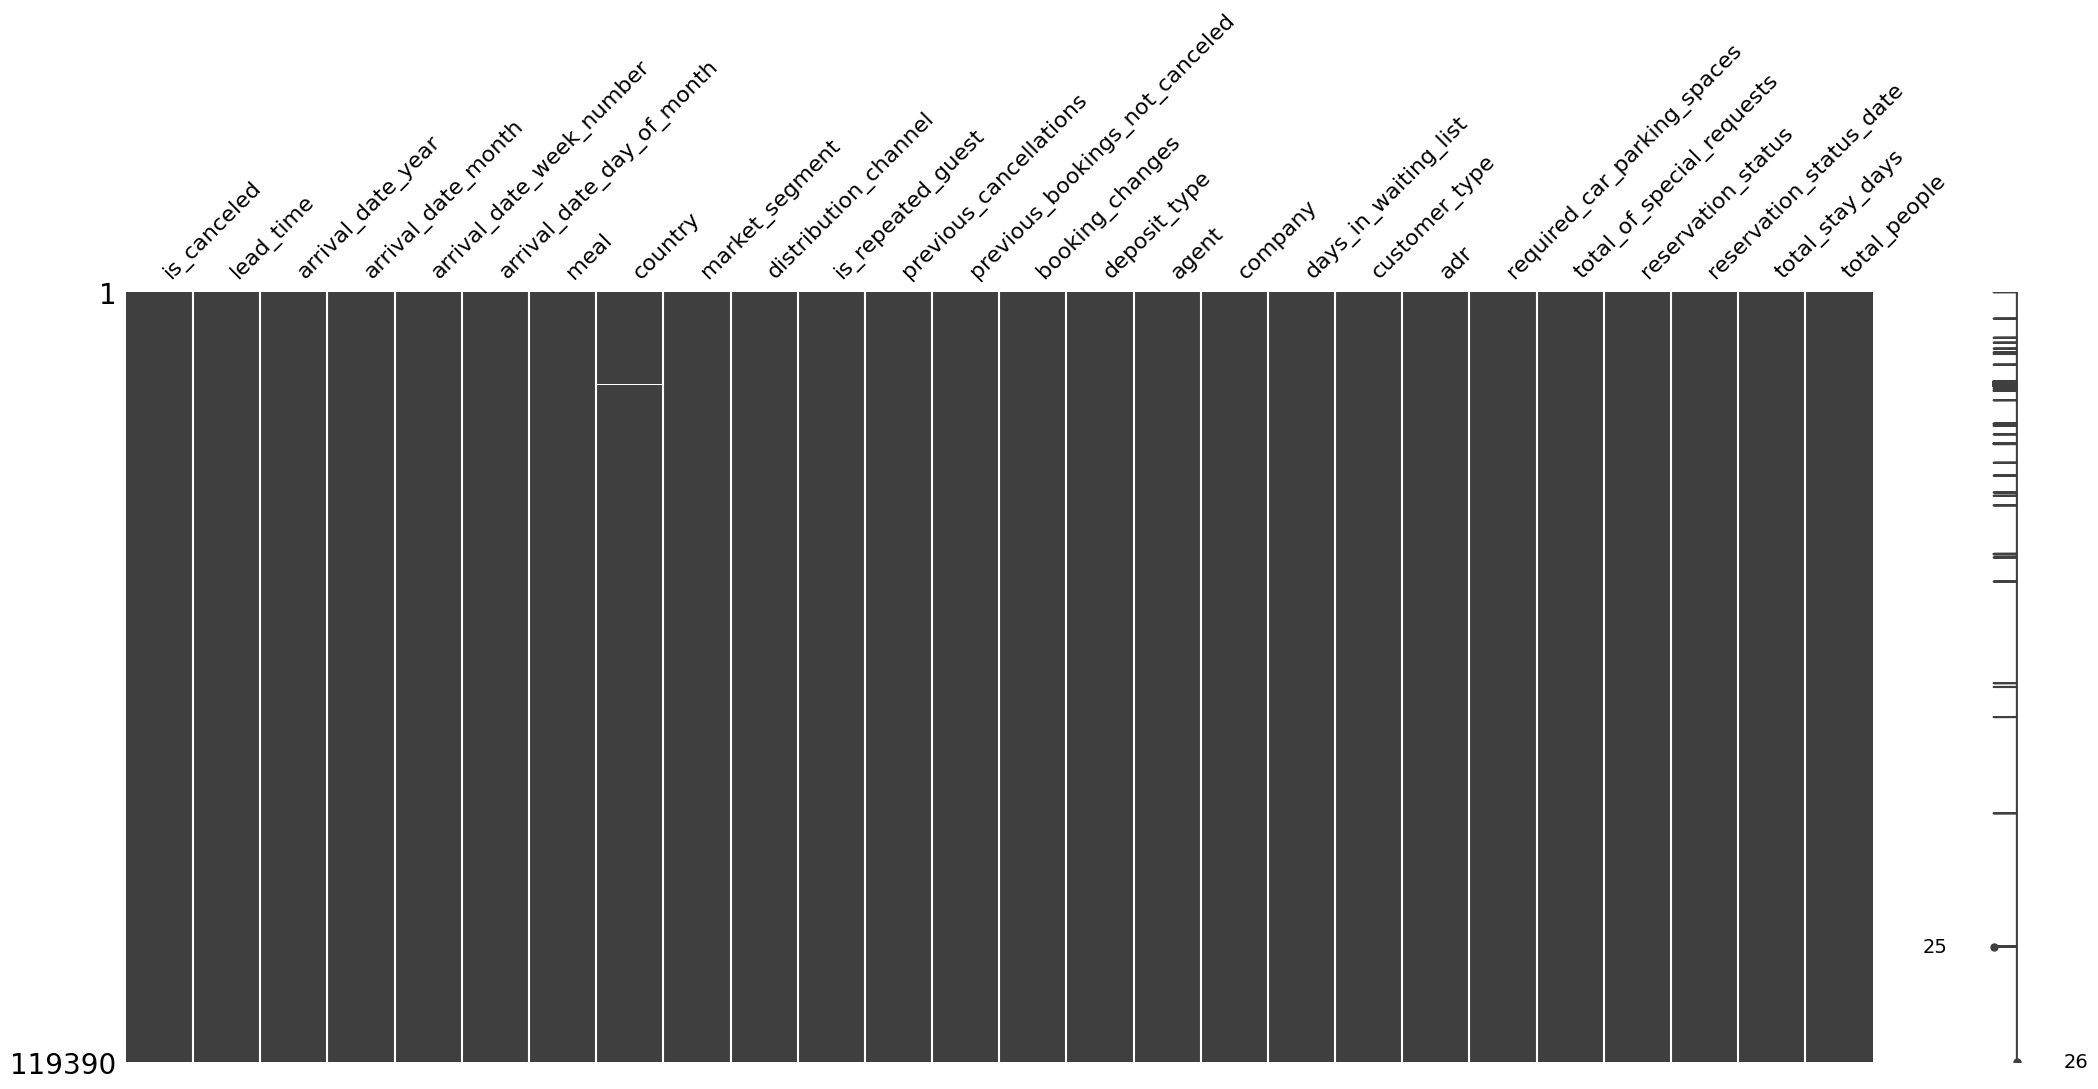

In [ ]:
matrix(cancel_df)

In [ ]:
country_count = cancel_df["country"].value_counts().reset_index()
country_count.columns = ["country","n"]
country_count["prop"] = country_count["n"]/country_count["n"].sum()
country_count

,country,n,prop
0,PRT,48590,0.408656
1,GBR,12129,0.102008
2,FRA,10415,0.087593
3,ESP,8568,0.072059
4,DEU,7287,0.061286
...,...,...,...
172,MRT,1,0.000008
173,KIR,1,0.000008
174,SDN,1,0.000008
175,ATF,1,0.000008


In [ ]:
cancel_df["country"] = cancel_df["country"].fillna("PRT")

In [ ]:
cancel_df.dropna(inplace=True)


In [ ]:
cancel_df = cancel_df.drop(columns=["agent", "company"])

In [ ]:
cancel_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 24 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
arrival_date_year:               int64             [2015, 2015, 2015, 20 ...
arrival_date_month:              object            ['July', 'July', 'Jul ...
arrival_date_week_number:        int64             [27, 27, 27, 27, 27,  ...
arrival_date_day_of_month:       int64             [1, 1, 1, 1, 1, 1, 1, ...
meal:                            object            ['BB       ', 'BB     ...
country:                         object            ['PRT', 'PRT', 'GBR', ...
market_segment:                  object            ['Direct', 'Direct',  ...
distribution_channel:            object            ['Direct', 'Direct',  ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bo

In [ ]:
canceled_df = cancel_df.copy()

In [ ]:
df_binarized = canceled_df.binarize()

In [ ]:
df_binarized['is_canceled'] = canceled_df['is_canceled']


In [ ]:
df_correlate = df_binarized.correlate(target="is_canceled__1")

In [ ]:
df_binarized.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 103 columns
lead_time__0.0_18.0:                     int64             [0, 0, 1, 1,  ...
lead_time__18.0_69.0:                    int64             [0, 0, 0, 0,  ...
lead_time__69.0_160.0:                   int64             [0, 0, 0, 0,  ...
lead_time__160.0_737.0:                  int64             [1, 1, 0, 0,  ...
arrival_date_week_number__1.0_16.0:      int64             [0, 0, 0, 0,  ...
arrival_date_week_number__16.0_28.0:     int64             [1, 1, 1, 1,  ...
arrival_date_week_number__28.0_38.0:     int64             [0, 0, 0, 0,  ...
arrival_date_week_number__38.0_53.0:     int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__1.0_8.0:      int64             [1, 1, 1, 1,  ...
arrival_date_day_of_month__8.0_16.0:     int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__16.0_23.0:    int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__23.0_31.0:    int64             [0, 0, 0, 0,  ...
adr__-6.4_

In [ ]:
df_correlate.head(10)

,feature,bin,correlation
23,is_canceled,1,1.000000
102,is_canceled,None,1.000000
22,is_canceled,0,-1.000000
98,reservation_status,Check-Out,-1.000000
97,reservation_status,Canceled,0.978433
82,deposit_type,Non Refund,0.481488
81,deposit_type,No Deposit,-0.477942
56,country,PRT,0.331560
71,previous_cancellations,1,0.274606
70,previous_cancellations,0,-0.270962


In [ ]:
df_correlate.plot_correlation_funnel()

In [ ]:
new_df = canceled_df.drop(columns=["reservation_status"])

###selecting important columns

In [ ]:
new_df = new_df[["is_canceled","deposit_type","country","previous_cancellations","lead_time","total_of_special_requests","market_segment","required_car_parking_spaces","booking_changes","distribution_channel","customer_type","previous_bookings_not_canceled","is_repeated_guest"]]

In [ ]:
new_df["country_prt"] = (new_df["country"]=="PRT").astype(int)
new_df["country_other"] = (new_df["country"]!="prt").astype(int)

In [ ]:
new_df.drop(columns=["country"],inplace=True)

In [ ]:
new_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 14 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type:                    object            ['No Deposit     ', ' ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
market_segment:                  object            ['Direct', 'Direct',  ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
distribution_channel:            object            ['Direct', 'Direct',  ...
customer_type:                   object            ['Transient', 'Transi ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt

##casual hypothesis

######Q1) will reducing lead time reduce cancellation??

In [ ]:
lead_time_df = new_df[["is_canceled","lead_time"]].copy()

In [ ]:
lead_time_df["lead_time_binned"] = pd.qcut(lead_time_df["lead_time"],q=4,duplicates="drop")

In [ ]:
lead_time_dummy = pd.get_dummies(lead_time_df["lead_time_binned"],drop_first=True)

In [ ]:
X = lead_time_dummy.astype(float)
Y = lead_time_df["is_canceled"].astype(float)

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.Logit(Y,X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.608661
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:               119386
Model:                          Logit   Df Residuals:                   119382
Method:                           MLE   Df Model:                            3
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.07662
Time:                        20:08:21   Log-Likelihood:                -72666.
converged:                       True   LL-Null:                       -78695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7643      0.016   -108.441      0.000      -1.796      -1.732
(18.0, 69.0]     

####logistic regression produces log(odds)

In [ ]:
np.exp(1.98) ## 160+ days - 7.2X risk of cancellation
np.exp(1.47) ## 69-160 days - 4.3X risk of cancellation
np.exp(1.18) ## 18-69 days - 3.25X risk of cancellation

np.float64(3.2543742028896707)

####consedering cofounders

In [ ]:
df = new_df.copy()
df["lead_time"] = pd.qcut(lead_time_df["lead_time"],q=4,duplicates="drop")

In [ ]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 14 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type:                    object            ['No Deposit     ', ' ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       category          [Interval(160.0, 737. ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
market_segment:                  object            ['Direct', 'Direct',  ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
distribution_channel:            object            ['Direct', 'Direct',  ...
customer_type:                   object            ['Transient', 'Transi ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt

In [ ]:
df = pd.get_dummies(df,drop_first=True)

In [ ]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 27 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 0, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
deposit_type_Non Refund     :    bool              [False, False, False, ...
deposit_type_Refundable     :    bool              [False, False, False, ...
lead_time_(18.0, 69.0]:          bool              [False, False, False, ...
lead_time_(

In [ ]:
for col in df.columns:
    if df[col].dtype == "bool":
      df[col] = df[col].astype(int)


In [ ]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 27 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 0, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
deposit_type_Non Refund     :    int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type_Refundable     :    int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time_(18.0, 69.0]:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time_(

In [ ]:
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

In [ ]:
x_train = train_df.drop(columns=["is_canceled"])
y_train = train_df["is_canceled"]
x_test = sm.add_constant(test_df.drop(columns=["is_canceled"]))
y_test = test_df["is_canceled"]

In [ ]:
Model = GLM(y_train,sm.add_constant(x_train),family=Binomial(),link=logit())
result = Model.fit_regularized(method = "elastic_net",alpha=0.01,L1_wt=1.0)

In [ ]:
pred_prob= result.predict(x_test)
roc_auc = roc_auc_score(y_test,pred_prob)
print(roc_auc)

0.8563725832405129


In [ ]:
pd.DataFrame(result.params)

,0
previous_cancellations,0.243115
total_of_special_requests,-0.529974
required_car_parking_spaces,-0.816411
booking_changes,-0.247128
previous_bookings_not_canceled,-0.123001
is_repeated_guest,0.000000
country_prt,0.787755
country_other,-1.161162
deposit_type_Non Refund,2.456508
deposit_type_Refundable,0.000000


In [ ]:
np.exp(0.438781)
### if we see the lead_time for 160+ days = 0.438781 which is 1.55X risk of cancellation but it goes down from 7X

np.float64(1.5508156215745403)